In [1]:
import pandas as pd
import re
from general_information import *


In [2]:
general_info = read_general_information()
actions = read_actions()
balances = read_balances()
payments = read_payments()

Временно обрежу все DataFrames.

In [3]:
# balances = balances[balances["ЛС"] < 10000]
balances

,ЛС,2025_1_start,2025_1_accr,2025_1_paid,2025_2_start,2025_2_accr,2025_2_paid,2025_3_start,2025_3_accr,2025_3_paid,...,2025_12_paid,2026_1_start,2026_1_accr,2026_1_paid,2026_2_start,2026_2_accr,2026_2_paid,2026_3_start,2026_3_accr,2026_3_paid
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150785,150817.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
150786,150818.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
150787,150819.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
150788,150820.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# payments = payments[payments["Номер"]<10000]
payments

,Номер,Дата оплаты,Сумма,Способ оплаты
0,15,24.01.2025,100.00,5.0
1,15,25.01.2026,1240.00,5.0
2,15,25.05.2025,293.96,5.0
3,15,25.06.2025,10.00,5.0
4,15,26.02.2025,289.56,5.0
...,...,...,...,...
1565014,147103,13.01.2026,11734.21,4.0
1565015,147103,13.03.2025,10041.17,NaN
1565016,147103,14.11.2025,11000.00,NaN
1565017,147103,20.02.2026,7200.57,NaN


In [5]:
# for key in actions.keys():
#     df = actions[key]["data"]
#     actions[key]["data"] = df[df["ЛС"] < 10000]
actions

{'Автодозвон': {'limit': 8000,
  'data': 1           ЛС                 Дата
  2           15  2025-11-01 00:00:00
  3           15  2025-12-01 00:00:00
  4           17  2025-04-01 00:00:00
  5           17  2026-03-01 00:00:00
  6           21  2025-01-01 00:00:00
  ...        ...                  ...
  113316  147085  2025-12-01 00:00:00
  113317  147098  2026-01-01 00:00:00
  113318  147100  2025-12-01 00:00:00
  113319  147103  2025-03-01 00:00:00
  113320  147103  2025-12-01 00:00:00
  
  [113319 rows x 2 columns],
  'stage': 'informing'},
 'E-mail': {'limit': 'нет ограничений',
  'data': 1          ЛС                 Дата
  2          25  2025-10-01 00:00:00
  3          25  2025-10-01 00:00:00
  4          25  2025-11-01 00:00:00
  5          25  2025-11-01 00:00:00
  6          25  2025-12-01 00:00:00
  ...       ...                  ...
  69055  147103  2025-05-01 00:00:00
  69056  147103  2025-08-01 00:00:00
  69057  147103  2025-11-01 00:00:00
  69058  147103  2025-12-01 00

In [6]:
# general_info = general_info[general_info["ЛС"] < 10000]
general_info

,ЛС,Возможность дистанционного отключения,Наличие телефона,Наличие льгот,Газификация дома,Город,ЯрОблИЕРЦ квитанция,Почта России квитанция,электронная квитанция,не проживает,ЧД,МКД,Общежитие,Установка Тамбур,Установка опора,Установка в квартире/доме,Установка лестничкая клетка
0,1,Нет,Нет,Нет,Да,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет
1,2,Нет,Нет,Нет,Нет,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет
2,3,Нет,Нет,Нет,Нет,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет
3,4,Нет,Нет,Нет,Да,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Да
4,5,Нет,Нет,Нет,Да,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150816,150817,Нет,Нет,Нет,Да,Да,Да,Нет,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет
150817,150818,Нет,Нет,Нет,Да,Да,Да,Нет,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет
150818,150819,Нет,Нет,Нет,Да,Да,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет
150819,150820,Нет,Нет,Нет,Да,Да,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет


In [7]:
def overdue_accounts(balances: pd.DataFrame,
                     payments: pd.DataFrame,
                     target_date,
                     balance_id_col: str = "ЛС",
                     payment_id_col: str = "Номер",
                     payment_date_col: str = "Дата оплаты",
                     payment_sum_col: str = "Сумма"):
    target_date = pd.to_datetime(target_date)

    # --- payments: суммы оплат по ЛС до заданной даты ---
    pay = payments.copy()
    pay[payment_date_col] = pd.to_datetime(pay[payment_date_col], dayfirst=True)
    pay = pay[pay[payment_date_col] <= target_date]

    pay_sum = (
        pay.groupby(payment_id_col, as_index=False)[payment_sum_col]
           .sum()
           .rename(columns={payment_id_col: balance_id_col, payment_sum_col: "paid_total"})
    )

    # --- balances: разбираем колонки вида 2025_1_start, 2025_1_accr, 2025_1_paid ---
    bal = balances.copy()

    pattern = re.compile(r"^(\d{4})_(\d{1,2})_(start|accr|paid)$")
    parsed_cols = []
    for c in bal.columns:
        m = pattern.match(str(c))
        if m:
            year, month, metric = int(m.group(1)), int(m.group(2)), m.group(3)
            parsed_cols.append((c, year, month, metric))

    if not parsed_cols:
        raise ValueError("Не нашёл колонок формата YYYY_M_start / YYYY_M_accr / YYYY_M_paid")

    # Берём только месяцы до target_date
    target_period = target_date.to_period("M")
    months = sorted({(y, m) for _, y, m, _ in parsed_cols if pd.Period(f"{y}-{m:02d}") <= target_period})

    rows = []
    for _, row in bal.iterrows():
        acc = row[balance_id_col]

        # первый доступный стартовый остаток из месяцев <= target_date
        opening = 0.0
        opening_set = False
        accrued = 0.0

        for y, m in months:
            start_col = f"{y}_{m}_start"
            accr_col = f"{y}_{m}_accr"

            if start_col in bal.columns and not opening_set:
                val = row[start_col]
                if pd.notna(val):
                    opening = float(val)
                    opening_set = True

            if accr_col in bal.columns:
                val = row[accr_col]
                if pd.notna(val):
                    accrued += float(val)

        paid = pay_sum.loc[pay_sum[balance_id_col] == acc, "paid_total"].sum()

        debt = opening + accrued - paid

        rows.append({
            balance_id_col: acc,
            "opening": opening,
            "accrued": accrued,
            "paid": paid,
            "debt": debt
        })

    result = pd.DataFrame(rows)

    overdue = result[result["debt"] > 1].copy()
    overdue_accounts_list = overdue[balance_id_col].tolist()

    return overdue_accounts_list, overdue.sort_values("debt", ascending=False), result

In [8]:
ls_list, overdue_df, full_df = overdue_accounts(
    balances=balances,
    payments=payments,
    target_date="2025-03-15"
)



In [9]:
overdue_df

,ЛС,opening,accrued,paid,debt
17112,17116.0,834.67,206280.04,4977.85,202136.86
8335,8338.0,158286.93,10503.69,0.00,168790.62
66497,66511.0,1104.95,152075.94,10.00,153170.89
27411,27418.0,127356.55,19942.09,2500.00,144798.64
18197,18201.0,140544.35,0.00,0.00,140544.35
...,...,...,...,...,...
73559,73574.0,5.97,9.90,14.85,1.02
19186,19190.0,1.02,10.41,10.41,1.02
41948,41958.0,8.90,20.82,28.70,1.02
42377,42387.0,9.90,20.82,29.70,1.02


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_to_payment(actions: dict, payments: pd.DataFrame,
                         id_col_actions="ЛС",
                         date_col_actions="Дата",
                         id_col_payments="Номер",
                         date_col_payments="Дата оплаты"):
    
    payments = payments.copy()
    payments[date_col_payments] = pd.to_datetime(payments[date_col_payments], dayfirst=True, errors="coerce")
    
    results = {}
    
    for action_name, action_data in actions.items():
        df = action_data["data"].copy()
        df[date_col_actions] = pd.to_datetime(df[date_col_actions])
        
        # merge: для каждого действия ищем ближайшую оплату после него
        merged = df.merge(payments, left_on=id_col_actions, right_on=id_col_payments, how="left")
        
        merged = merged[merged[date_col_payments] >= merged[date_col_actions]]
        
        # берём ближайшую оплату
        merged["delta"] = (merged[date_col_payments] - merged[date_col_actions]).dt.days
        
        merged = merged.sort_values(["ЛС", date_col_actions, "delta"])
        merged = merged.groupby([id_col_actions, date_col_actions], as_index=False).first()
        
        results[action_name] = merged["delta"].dropna()
        
        # plot histogram
    
    return results



def build_stats_table(results: dict):
    rows = []

    for action_name, deltas in results.items():
        if len(deltas) == 0:
            continue

        deltas = pd.Series(deltas).dropna()

        stats = {
            "action": action_name,
            "count": len(deltas),
            "mean_days": deltas.mean(),
            "median_days": deltas.median(),
            "std_days": deltas.std(),

            "p25": deltas.quantile(0.25),
            "p50": deltas.quantile(0.5),   # дублирует медиану, но пусть будет явно
            "p75": deltas.quantile(0.75),
            "p90": deltas.quantile(0.9),

            "min_days": deltas.min(),
            "max_days": deltas.max(),

            # ключевая бизнес-метрика
            "paid_1d_share": (deltas <= 1).mean(),
            "paid_3d_share": (deltas <= 3).mean(),
            "paid_7d_share": (deltas <= 7).mean(),
            "paid_14d_share": (deltas <= 14).mean(),
        }

        rows.append(stats)

    df_stats = pd.DataFrame(rows)

    # сортировка — самые эффективные сверху (например по 7 дням)
    if not df_stats.empty:
        df_stats = df_stats.sort_values("paid_7d_share", ascending=False)

    return df_stats

In [20]:
action_repayment = plot_time_to_payment(actions, payments)

df = build_stats_table(action_repayment)
df

,action,count,mean_days,median_days,std_days,p25,p50,p75,p90,min_days,max_days,paid_1d_share,paid_3d_share,paid_7d_share,paid_14d_share
7,Ограничение,1984,21.817540,1.0,54.989578,0.0,1.0,12.0,66.7,0,394,0.572581,0.647177,0.719254,0.771169
3,Обзвон оператором,19480,27.432546,19.0,36.058307,6.0,19.0,32.0,61.0,0,385,0.116324,0.182341,0.297895,0.427207
6,Уведомление о введении ограничения,68789,38.010132,20.0,51.188961,9.0,20.0,46.0,90.0,0,444,0.070622,0.119220,0.207344,0.359505
9,Получение судебного приказа или ИЛ,1887,67.339693,46.0,71.282767,21.0,46.0,86.0,158.0,0,420,0.063593,0.099099,0.146794,0.195548
5,Выезд к абоненту,4095,42.446154,23.0,49.501057,12.0,23.0,52.0,108.0,0,358,0.031258,0.053480,0.114042,0.330403
8,Заявление о выдаче судебного приказа,1945,106.431362,96.0,87.718836,25.0,96.0,159.0,228.6,0,420,0.022622,0.043702,0.089460,0.157326
0,Автодозвон,64799,51.140496,28.0,63.321525,16.0,28.0,56.0,122.0,0,453,0.015849,0.027454,0.064307,0.217256
1,E-mail,42533,41.034867,28.0,44.160163,17.0,28.0,47.0,82.0,0,443,0.017398,0.030212,0.057532,0.191193
2,СМС,25965,33.623185,24.0,30.783174,16.0,24.0,41.0,68.0,0,351,0.015945,0.024803,0.043058,0.156711
4,Претензия,2734,78.976957,48.0,83.027038,32.0,48.0,85.0,189.7,0,453,0.012436,0.019386,0.030724,0.084126


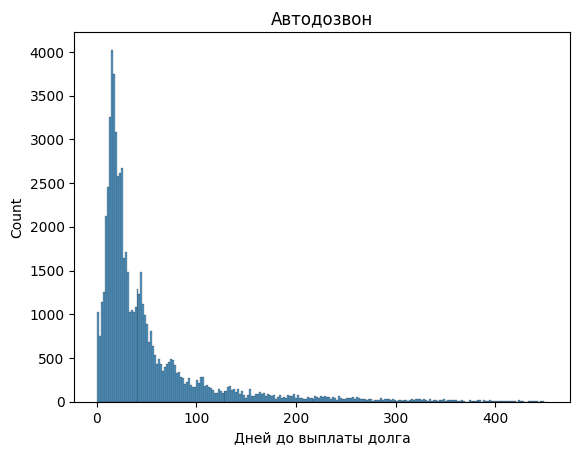

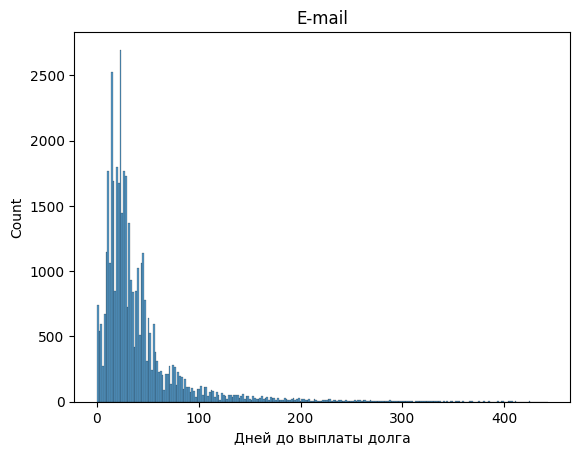

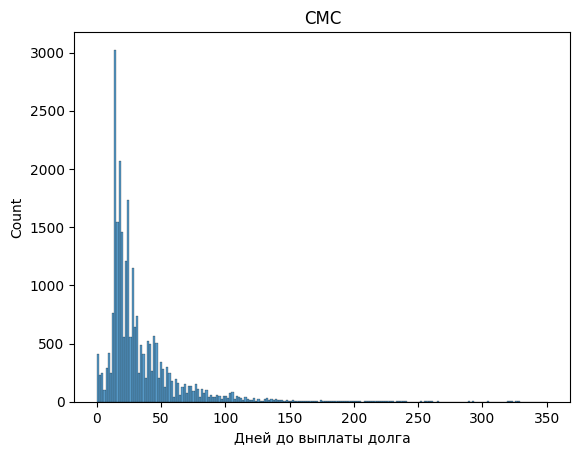

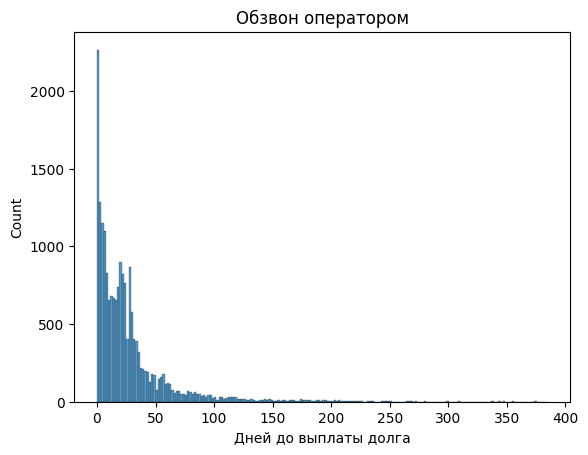

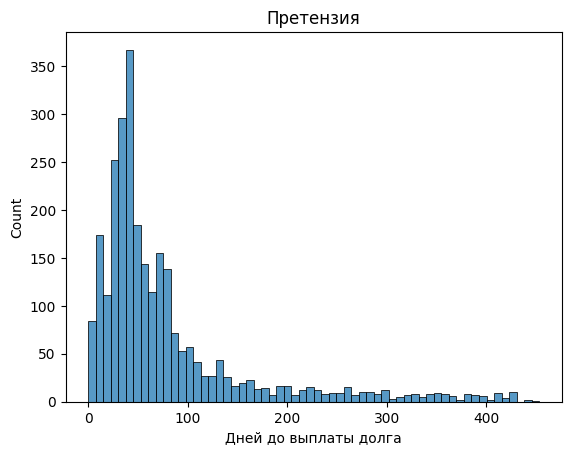

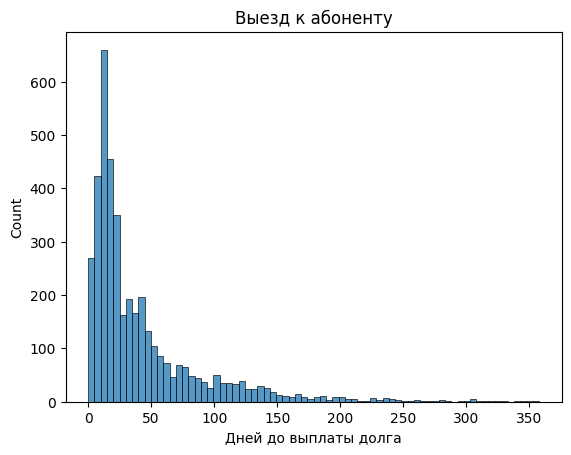

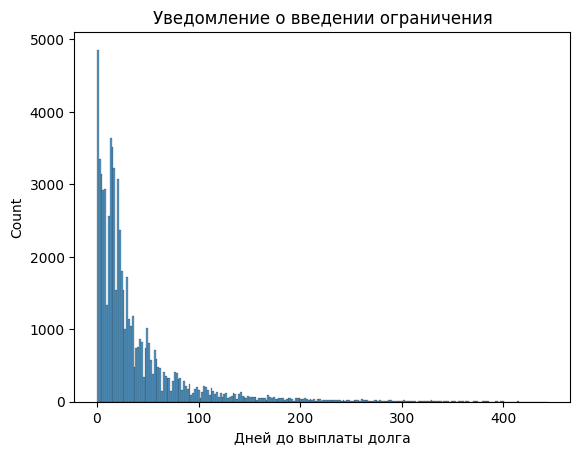

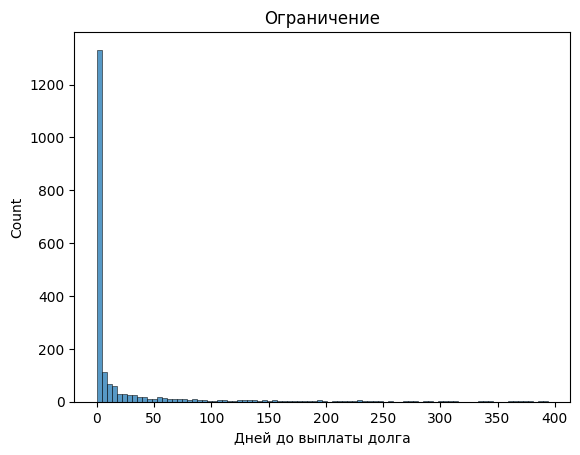

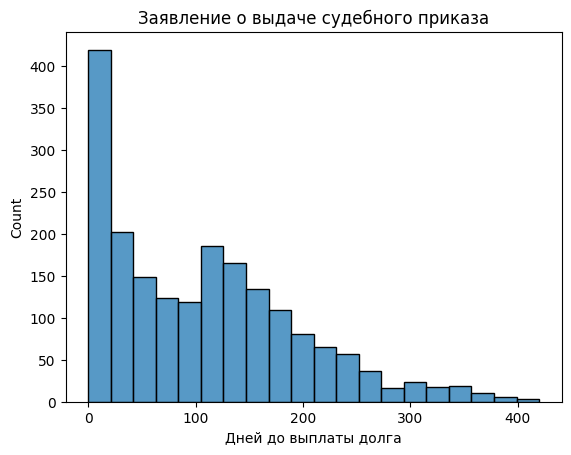

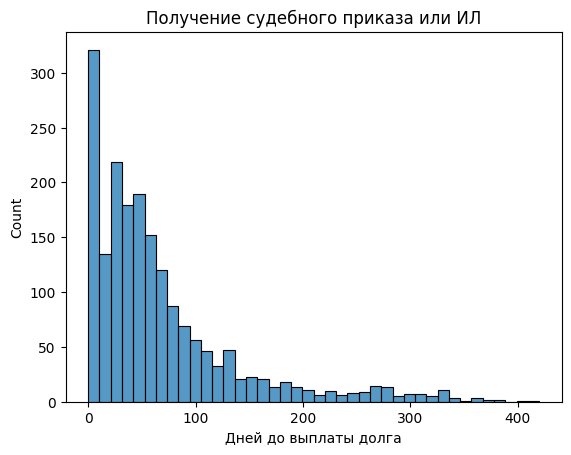

In [25]:
for key, value in action_repayment.items():
    plt.figure()
    sns.histplot(x = value)
    plt.title(key)
    plt.xlabel("Дней до выплаты долга")

    